# 01: Market Calibration

This notebook tests whether average-market closing probabilities are consistent with the outcomes that actually occurred. In practical terms, if the market assigns roughly 60% probability to a group of selections, we expect close to 60% of them to win if the probabilities are well calibrated.

### Research question

How well do closing market probabilities match observed football outcomes across the full sample, outcome types, leagues, and seasons?

### Method

- average-market closing odds are converted to proportional no-vig probabilities;
- probabilities are grouped into ten fixed 0.10-wide bins;
- groups with `n < 200` are retained in tables but treated as sparse;
- uncertainty is estimated with 2,000 match-level cluster bootstrap replicates;
- forecast quality is summarized with the unscaled multiclass Brier Score;
- a simple climatology forecast is used as a descriptive benchmark.

### Outputs

The notebook exports calibration and Brier tables to `data/processed/` for the Power BI dashboard.


## 1. Setup and database connection

Load the analysis libraries, resolve the repository path, read the local database configuration from `.env`, and confirm that PostgreSQL is reachable.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [2]:
dotenv_path = find_dotenv(usecwd=True)

if not dotenv_path:
    raise FileNotFoundError(".env file not found.")

load_dotenv(dotenv_path)

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

REPO_ROOT = Path(dotenv_path).parent

In [3]:
database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=int(DB_PORT),
    database=DB_NAME,
)

engine = create_engine(
    database_url,
    pool_pre_ping=True,
)

In [4]:
connection_test = text("""
SELECT
    current_database() AS database_name,
    current_user AS user_name;
""")

with engine.connect() as connection:
    result = connection.execute(connection_test).fetchone()

print("Connected to database:", result.database_name)
print("Database user:", result.user_name)

Connected to database: football_market_efficiency
Database user: postgres


## 2. Load the calibration sample from SQL

Read the validated match and selection fields needed for calibration. The analysis uses only rows that are eligible for the average-market closing-probability metrics.


In [5]:
query = text("""
SELECT
    s.match_id,
    m.season,
    m.div,
    s.selection_type,
    s.selection_won,
    s.market_no_vig_probability,
    s.avg_market_calibration_eligible
FROM analytics.fact_selections AS s
INNER JOIN analytics.fact_matches AS m
    ON s.match_id = m.match_id
ORDER BY
    s.match_id,
    s.selection_type;
""")

with engine.connect() as connection:
    df = pd.read_sql(query, con=connection)

df_calibration = (
    df.loc[df["avg_market_calibration_eligible"]]
    .copy()
)

assert len(df) == 37_377
assert df["match_id"].nunique() == 12_459
assert len(df_calibration) == 37_374
assert df_calibration["match_id"].nunique() == 12_458

display(df.head())

,match_id,season,div,selection_type,selection_won,market_no_vig_probability,avg_market_calibration_eligible
0,2019_20_D1_20190816_Bayern Munich_Hertha,2019_20,D1,A,0,0.061155,True
1,2019_20_D1_20190816_Bayern Munich_Hertha,2019_20,D1,D,1,0.119787,True
2,2019_20_D1_20190816_Bayern Munich_Hertha,2019_20,D1,H,0,0.819058,True
3,2019_20_D1_20190817_Dortmund_Augsburg,2019_20,D1,A,0,0.052562,True
4,2019_20_D1_20190817_Dortmund_Augsburg,2019_20,D1,D,0,0.118686,True


## 3. Define fixed probability bins

Use ten equal-width bins from 0 to 1. The boundaries and the `n >= 200` interpretation rule are fixed before subgroup results are interpreted so the analysis is not tuned to the observed pattern.


In [6]:
MIN_BIN_N = 200

BIN_LABELS = [
    "[0.00, 0.10)",
    "[0.10, 0.20)",
    "[0.20, 0.30)",
    "[0.30, 0.40)",
    "[0.40, 0.50)",
    "[0.50, 0.60)",
    "[0.60, 0.70)",
    "[0.70, 0.80)",
    "[0.80, 0.90)",
    "[0.90, 1.00]",
]

BIN_EDGES = np.array([
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    np.nextafter(1.0, 2.0),
])

In [7]:
df_calibration["probability_bin"] = pd.cut(
    df_calibration["market_no_vig_probability"],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
)

assert df_calibration["probability_bin"].notna().all()

display(
    df_calibration["probability_bin"]
    .value_counts(sort=False)
)

probability_bin
[0.00, 0.10)     1169
[0.10, 0.20)     5629
[0.20, 0.30)    13850
[0.30, 0.40)     6485
[0.40, 0.50)     4014
[0.50, 0.60)     2878
[0.60, 0.70)     1888
[0.70, 0.80)     1098
[0.80, 0.90)      357
[0.90, 1.00]        6
Name: count, dtype: int64

## 4. Build the overall calibration table

For each probability bin, compare the mean predicted probability with the observed win rate. The calibration gap is defined as observed rate minus predicted probability.


In [8]:
def build_calibration_table(data, group_cols=None):
    if group_cols is None:
        group_cols = []

    grouped = group_cols + ["probability_bin"]

    result = (
        data
        .groupby(grouped, observed=False)
        .agg(
            n=("selection_won", "size"),
            mean_predicted_probability=(
                "market_no_vig_probability",
                "mean",
            ),
            observed_outcome_rate=(
                "selection_won",
                "mean",
            ),
        )
        .reset_index()
    )

    result["calibration_gap"] = (
        result["observed_outcome_rate"]
        - result["mean_predicted_probability"]
    )

    result["sparse"] = result["n"] < MIN_BIN_N

    return result

In [9]:
overall_calibration = build_calibration_table(
    df_calibration
)

display(overall_calibration)

,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse
0,"[0.00, 0.10)",1169,0.076143,0.073567,-0.002575,False
1,"[0.10, 0.20)",5629,0.157817,0.144608,-0.013209,False
2,"[0.20, 0.30)",13850,0.256772,0.253935,-0.002837,False
3,"[0.30, 0.40)",6485,0.340625,0.337240,-0.003385,False
4,"[0.40, 0.50)",4014,0.447432,0.453662,0.006231,False
5,"[0.50, 0.60)",2878,0.547968,0.561154,0.013185,False
6,"[0.60, 0.70)",1888,0.647174,0.680085,0.032910,False
7,"[0.70, 0.80)",1098,0.743275,0.756831,0.013556,False
8,"[0.80, 0.90)",357,0.837238,0.831933,-0.005305,False
9,"[0.90, 1.00]",6,0.913213,1.000000,0.086787,True


## 5. Calculate the multiclass Brier Score

The Brier Score measures the squared error of the full home-draw-away probability forecast for each match. This project uses the unscaled three-outcome version, so the same definition is used in SQL, Python, and Power BI.


In [10]:
df_calibration["squared_error"] = (
    df_calibration["market_no_vig_probability"]
    - df_calibration["selection_won"]
) ** 2

match_brier = (
    df_calibration
    .groupby(
        ["match_id", "season", "div"],
        as_index=False
    )
    .agg(
        brier_score=("squared_error", "sum")
    )
)

overall_brier = match_brier["brier_score"].mean()

print("Overall Brier Score:", overall_brier)

Overall Brier Score: 0.5768930352942788


In [11]:
brier_sql_query = text("""
SELECT
    AVG(match_brier_score) AS mean_brier_score
FROM (
    SELECT
        match_id,
        SUM(
            POWER(
                market_no_vig_probability - selection_won,
                2
            )
        ) AS match_brier_score
    FROM analytics.fact_selections
    WHERE avg_market_calibration_eligible
    GROUP BY match_id
) AS match_scores;
""")

with engine.connect() as connection:
    sql_brier = pd.read_sql(
        brier_sql_query,
        con=connection
    ).loc[0, "mean_brier_score"]

assert np.isclose(
    overall_brier,
    sql_brier,
    atol=1e-10,
)

print("Python Brier:", overall_brier)
print("SQL Brier:", sql_brier)

Python Brier: 0.5768930352942788
SQL Brier: 0.5768930352942788


### Climatology benchmark

As a simple reference, assign every match the unconditional home, draw, and away frequencies observed in the analysis sample. This is an in-sample benchmark for forecast quality, not a betting strategy or an out-of-sample model.


In [12]:
empirical_rates = (
    df_calibration
    .groupby("selection_type")["selection_won"]
    .mean()
)

df_calibration["benchmark_probability"] = (
    df_calibration["selection_type"]
    .map(empirical_rates)
)

df_calibration["benchmark_squared_error"] = (
    df_calibration["benchmark_probability"]
    - df_calibration["selection_won"]
) ** 2

benchmark_match_brier = (
    df_calibration
    .groupby("match_id")["benchmark_squared_error"]
    .sum()
)

benchmark_brier = benchmark_match_brier.mean()

print("Market Brier:", overall_brier)
print("Climatology Brier:", benchmark_brier)

Market Brier: 0.5768930352942788
Climatology Brier: 0.6503581621662498


## 6. Compare Brier Score by league and season

Aggregate match-level Brier Scores by league and by season to check whether forecast error changes across major segments of the dataset.


In [13]:
brier_by_league = (
    match_brier
    .groupby("div", as_index=False)
    .agg(
        n_matches=("match_id", "size"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values("mean_brier_score")
)

display(brier_by_league)

,div,n_matches,mean_brier_score
1,E0,2660,0.571683
3,I1,2660,0.571957
4,SP1,2659,0.576517
0,D1,2142,0.578664
2,F1,2337,0.587246


In [14]:
brier_by_season = (
    match_brier
    .groupby("season", as_index=False)
    .agg(
        n_matches=("match_id", "size"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values("season")
)

display(brier_by_season)

,season,n_matches,mean_brier_score
0,2019_20,1725,0.578292
1,2020_21,1826,0.579747
2,2021_22,1826,0.580101
3,2022_23,1826,0.580590
4,2023_24,1752,0.566129
5,2024_25,1752,0.570709
6,2025_26,1751,0.582294


## 7. Compare calibration by outcome type

Build separate reliability tables for home wins, draws, and away wins. This helps show whether the pooled market result hides outcome-specific calibration patterns.


In [15]:
calibration_by_selection = build_calibration_table(
    df_calibration,
    group_cols=["selection_type"],
)

display(calibration_by_selection)

,selection_type,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse
0,A,"[0.00, 0.10)",884,0.073694,0.075792,0.002097,False
1,A,"[0.10, 0.20)",2590,0.153327,0.138224,-0.015103,False
2,A,"[0.20, 0.30)",3093,0.250387,0.240866,-0.009521,False
3,A,"[0.30, 0.40)",2485,0.346108,0.348089,0.001981,False
4,A,"[0.40, 0.50)",1535,0.446014,0.470358,0.024345,False
5,A,"[0.50, 0.60)",1016,0.547768,0.566929,0.019161,False
6,A,"[0.60, 0.70)",563,0.644614,0.674956,0.030342,False
7,A,"[0.70, 0.80)",252,0.739552,0.797619,0.058067,False
8,A,"[0.80, 0.90)",40,0.823811,0.775000,-0.048811,True
9,A,"[0.90, 1.00]",0,NaN,NaN,NaN,True


## 8. Compare calibration by league and season

Repeat the fixed-bin calibration calculation for each league and season. These tables are descriptive until bootstrap uncertainty is added in the next steps.


In [16]:
calibration_by_league = build_calibration_table(
    df_calibration,
    group_cols=["div"],
)

display(calibration_by_league)

,div,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse
0,D1,"[0.00, 0.10)",249,0.073390,0.072289,-0.001101,False
1,D1,"[0.10, 0.20)",938,0.157647,0.146055,-0.011592,False
2,D1,"[0.20, 0.30)",2474,0.253725,0.263137,0.009411,False
3,D1,"[0.30, 0.40)",957,0.347482,0.342738,-0.004744,False
4,D1,"[0.40, 0.50)",747,0.448173,0.420348,-0.027825,False
5,D1,"[0.50, 0.60)",444,0.547047,0.551802,0.004755,False
6,D1,"[0.60, 0.70)",326,0.645320,0.680982,0.035662,False
7,D1,"[0.70, 0.80)",191,0.749376,0.764398,0.015022,True
8,D1,"[0.80, 0.90)",97,0.842071,0.804124,-0.037947,True
9,D1,"[0.90, 1.00]",3,0.911938,1.000000,0.088062,True


In [17]:
calibration_by_season = build_calibration_table(
    df_calibration,
    group_cols=["season"],
)

display(calibration_by_season)

,season,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse
0,2019_20,"[0.00, 0.10)",198,0.072988,0.080808,0.007820,True
1,2019_20,"[0.10, 0.20)",779,0.156941,0.150193,-0.006749,False
2,2019_20,"[0.20, 0.30)",1853,0.257116,0.250405,-0.006712,False
3,2019_20,"[0.30, 0.40)",943,0.340238,0.351007,0.010769,False
4,2019_20,"[0.40, 0.50)",541,0.447957,0.452865,0.004908,False
...,...,...,...,...,...,...,...
65,2025_26,"[0.50, 0.60)",389,0.547132,0.542416,-0.004715,False
66,2025_26,"[0.60, 0.70)",263,0.645038,0.676806,0.031768,False
67,2025_26,"[0.70, 0.80)",134,0.743336,0.776119,0.032783,True
68,2025_26,"[0.80, 0.90)",30,0.836194,0.900000,0.063806,True


## 9. Define the match-cluster bootstrap

Home, draw, and away selections from the same match are not independent. The bootstrap therefore resamples complete `match_id` clusters and keeps all three selections together in every replicate.


In [18]:
N_BOOTSTRAP = 2_000
RANDOM_SEED = 42
N_BINS = len(BIN_LABELS)

In [19]:
def bootstrap_calibration(
    data,
    n_bootstrap=N_BOOTSTRAP,
    seed=RANDOM_SEED,
):
    ordered = (
        data
        .sort_values(["match_id", "selection_type"])
        .copy()
    )

    cluster_sizes = (
        ordered
        .groupby("match_id", sort=False)
        .size()
        .to_numpy()
    )

    if not np.all(cluster_sizes == cluster_sizes[0]):
        raise ValueError(
            "Clusters do not contain the same number of rows."
        )

    cluster_size = int(cluster_sizes[0])
    n_matches = len(cluster_sizes)

    probabilities = (
        ordered["market_no_vig_probability"]
        .to_numpy()
        .reshape(n_matches, cluster_size)
    )

    outcomes = (
        ordered["selection_won"]
        .to_numpy()
        .reshape(n_matches, cluster_size)
    )

    bin_codes = (
        ordered["probability_bin"]
        .cat.codes
        .to_numpy()
        .reshape(n_matches, cluster_size)
    )

    predicted_boot = np.full(
        (n_bootstrap, N_BINS),
        np.nan,
    )

    observed_boot = np.full(
        (n_bootstrap, N_BINS),
        np.nan,
    )

    gap_boot = np.full(
        (n_bootstrap, N_BINS),
        np.nan,
    )

    rng = np.random.default_rng(seed)

    for i in range(n_bootstrap):
        sampled_matches = rng.integers(
            0,
            n_matches,
            size=n_matches,
        )

        rep_probabilities = (
            probabilities[sampled_matches]
            .ravel()
        )

        rep_outcomes = (
            outcomes[sampled_matches]
            .ravel()
        )

        rep_bins = (
            bin_codes[sampled_matches]
            .ravel()
        )

        counts = np.bincount(
            rep_bins,
            minlength=N_BINS,
        )

        predicted_sum = np.bincount(
            rep_bins,
            weights=rep_probabilities,
            minlength=N_BINS,
        )

        observed_sum = np.bincount(
            rep_bins,
            weights=rep_outcomes,
            minlength=N_BINS,
        )

        predicted_mean = np.divide(
            predicted_sum,
            counts,
            out=np.full(N_BINS, np.nan),
            where=counts > 0,
        )

        observed_mean = np.divide(
            observed_sum,
            counts,
            out=np.full(N_BINS, np.nan),
            where=counts > 0,
        )

        predicted_boot[i] = predicted_mean
        observed_boot[i] = observed_mean
        gap_boot[i] = observed_mean - predicted_mean

    def get_ci(values):
        lower = np.full(N_BINS, np.nan)
        upper = np.full(N_BINS, np.nan)

        for bin_number in range(N_BINS):
            valid_values = values[:, bin_number]
            valid_values = valid_values[
                ~np.isnan(valid_values)
            ]

            if len(valid_values) > 0:
                lower[bin_number] = np.percentile(
                    valid_values,
                    2.5,
                )

                upper[bin_number] = np.percentile(
                    valid_values,
                    97.5,
                )

        return lower, upper

    predicted_low, predicted_high = get_ci(
        predicted_boot
    )

    observed_low, observed_high = get_ci(
        observed_boot
    )

    gap_low, gap_high = get_ci(
        gap_boot
    )

    return pd.DataFrame({
        "probability_bin": BIN_LABELS,
        "predicted_ci_low": predicted_low,
        "predicted_ci_high": predicted_high,
        "observed_ci_low": observed_low,
        "observed_ci_high": observed_high,
        "gap_ci_low": gap_low,
        "gap_ci_high": gap_high,
    })

## 10. Add overall bootstrap intervals

Run the cluster bootstrap for the pooled sample and merge 95% confidence intervals into the overall calibration table.


In [20]:
overall_bootstrap = bootstrap_calibration(
    df_calibration
)

overall_calibration = (
    overall_calibration
    .merge(
        overall_bootstrap,
        on="probability_bin",
        how="left",
    )
)

display(overall_calibration)

,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse,predicted_ci_low,predicted_ci_high,observed_ci_low,observed_ci_high,gap_ci_low,gap_ci_high
0,"[0.00, 0.10)",1169,0.076143,0.073567,-0.002575,False,0.075221,0.077131,0.059472,0.089049,-0.016777,0.012938
1,"[0.10, 0.20)",5629,0.157817,0.144608,-0.013209,False,0.157215,0.158428,0.135669,0.152982,-0.022053,-0.004712
2,"[0.20, 0.30)",13850,0.256772,0.253935,-0.002837,False,0.256316,0.257261,0.247453,0.260214,-0.009322,0.003461
3,"[0.30, 0.40)",6485,0.340625,0.337240,-0.003385,False,0.340056,0.341207,0.329742,0.344244,-0.010864,0.003614
4,"[0.40, 0.50)",4014,0.447432,0.453662,0.006231,False,0.446488,0.448312,0.437908,0.468899,-0.009486,0.021486
5,"[0.50, 0.60)",2878,0.547968,0.561154,0.013185,False,0.546899,0.549014,0.542573,0.578345,-0.005116,0.030258
6,"[0.60, 0.70)",1888,0.647174,0.680085,0.032910,False,0.645851,0.648481,0.659765,0.702281,0.012568,0.054682
7,"[0.70, 0.80)",1098,0.743275,0.756831,0.013556,False,0.741657,0.744913,0.730876,0.780900,-0.012748,0.037779
8,"[0.80, 0.90)",357,0.837238,0.831933,-0.005305,False,0.834549,0.839915,0.794354,0.870622,-0.043060,0.033429
9,"[0.90, 1.00]",6,0.913213,1.000000,0.086787,True,0.905165,0.921900,1.000000,1.000000,0.078100,0.094835


## 11. Add bootstrap intervals to segmented tables

Apply the same match-level resampling logic to outcome type, league, and season. This keeps the uncertainty method consistent across the main calibration views.


In [21]:
selection_bootstrap_tables = []

selection_order = ["H", "D", "A"]

for i, selection_type in enumerate(selection_order):
    subset = df_calibration.loc[
        df_calibration["selection_type"]
        == selection_type
    ].copy()

    point_estimates = build_calibration_table(
        subset
    )

    intervals = bootstrap_calibration(
        subset,
        seed=RANDOM_SEED + i + 1,
    )

    result = (
        point_estimates
        .merge(
            intervals,
            on="probability_bin",
            how="left",
        )
    )

    result.insert(
        0,
        "selection_type",
        selection_type,
    )

    selection_bootstrap_tables.append(result)

calibration_by_selection = pd.concat(
    selection_bootstrap_tables,
    ignore_index=True,
)

display(calibration_by_selection)

,selection_type,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse,predicted_ci_low,predicted_ci_high,observed_ci_low,observed_ci_high,gap_ci_low,gap_ci_high
0,H,"[0.00, 0.10)",171,0.081511,0.064327,-0.017183,True,0.079308,0.083678,0.030116,0.101527,-0.051840,0.020078
1,H,"[0.10, 0.20)",1123,0.157233,0.140695,-0.016538,False,0.155556,0.158876,0.120362,0.161922,-0.036872,0.004612
2,H,"[0.20, 0.30)",1856,0.253785,0.226832,-0.026953,False,0.252455,0.255051,0.208398,0.246226,-0.045566,-0.007715
3,H,"[0.30, 0.40)",2475,0.351398,0.336970,-0.014428,False,0.350231,0.352612,0.318362,0.356972,-0.033141,0.005492
4,H,"[0.40, 0.50)",2478,0.448316,0.443099,-0.005217,False,0.447232,0.449481,0.422756,0.463345,-0.025517,0.015165
5,H,"[0.50, 0.60)",1861,0.548072,0.558302,0.010230,False,0.546788,0.549315,0.535287,0.581516,-0.012765,0.033501
6,H,"[0.60, 0.70)",1325,0.648262,0.682264,0.034002,False,0.646718,0.649773,0.657078,0.707819,0.008933,0.059308
7,H,"[0.70, 0.80)",846,0.744383,0.744681,0.000297,False,0.742462,0.746354,0.717044,0.774942,-0.027570,0.030064
8,H,"[0.80, 0.90)",317,0.838932,0.839117,0.000185,False,0.836098,0.841727,0.797147,0.878788,-0.041212,0.039519
9,H,"[0.90, 1.00]",6,0.913213,1.000000,0.086787,True,0.905238,0.921900,1.000000,1.000000,0.078100,0.094762


In [22]:
league_bootstrap_tables = []

for i, div in enumerate(sorted(df_calibration["div"].unique())):
    subset = df_calibration.loc[
        df_calibration["div"] == div
    ].copy()

    point_estimates = build_calibration_table(subset)

    intervals = bootstrap_calibration(
        subset,
        seed=RANDOM_SEED + 100 + i,
    )

    result = point_estimates.merge(
        intervals,
        on="probability_bin",
        how="left",
    )

    result.insert(0, "div", div)

    league_bootstrap_tables.append(result)

calibration_by_league = pd.concat(
    league_bootstrap_tables,
    ignore_index=True,
)

display(calibration_by_league)

,div,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse,predicted_ci_low,predicted_ci_high,observed_ci_low,observed_ci_high,gap_ci_low,gap_ci_high
0,D1,"[0.00, 0.10)",249,0.073390,0.072289,-0.001101,False,0.071448,0.075362,0.043137,0.105269,-0.030679,0.031889
1,D1,"[0.10, 0.20)",938,0.157647,0.146055,-0.011592,False,0.155967,0.159135,0.124229,0.167034,-0.033224,0.009550
2,D1,"[0.20, 0.30)",2474,0.253725,0.263137,0.009411,False,0.252589,0.254872,0.247576,0.278255,-0.006141,0.024268
3,D1,"[0.30, 0.40)",957,0.347482,0.342738,-0.004744,False,0.345765,0.349123,0.320578,0.366476,-0.026361,0.018827
4,D1,"[0.40, 0.50)",747,0.448173,0.420348,-0.027825,False,0.445944,0.450274,0.384916,0.457342,-0.063831,0.008779
5,D1,"[0.50, 0.60)",444,0.547047,0.551802,0.004755,False,0.544415,0.549589,0.505720,0.598746,-0.041814,0.052263
6,D1,"[0.60, 0.70)",326,0.645320,0.680982,0.035662,False,0.642294,0.648362,0.629630,0.732361,-0.015013,0.087602
7,D1,"[0.70, 0.80)",191,0.749376,0.764398,0.015022,True,0.745648,0.753535,0.702128,0.824752,-0.046371,0.075103
8,D1,"[0.80, 0.90)",97,0.842071,0.804124,-0.037947,True,0.837354,0.846953,0.725490,0.879521,-0.114368,0.037250
9,D1,"[0.90, 1.00]",3,0.911938,1.000000,0.088062,True,0.905238,0.924823,1.000000,1.000000,0.075177,0.094762


In [23]:
season_bootstrap_tables = []

for i, season in enumerate(sorted(df_calibration["season"].unique())):
    subset = df_calibration.loc[
        df_calibration["season"] == season
    ].copy()

    point_estimates = build_calibration_table(subset)

    intervals = bootstrap_calibration(
        subset,
        seed=RANDOM_SEED + 200 + i,
    )

    result = point_estimates.merge(
        intervals,
        on="probability_bin",
        how="left",
    )

    result.insert(0, "season", season)

    season_bootstrap_tables.append(result)

calibration_by_season = pd.concat(
    season_bootstrap_tables,
    ignore_index=True,
)

display(calibration_by_season)

,season,probability_bin,n,mean_predicted_probability,observed_outcome_rate,calibration_gap,sparse,predicted_ci_low,predicted_ci_high,observed_ci_low,observed_ci_high,gap_ci_low,gap_ci_high
0,2019_20,"[0.00, 0.10)",198,0.072988,0.080808,0.007820,True,0.070547,0.075473,0.045714,0.121495,-0.027218,0.048134
1,2019_20,"[0.10, 0.20)",779,0.156941,0.150193,-0.006749,False,0.155280,0.158663,0.126285,0.175037,-0.030619,0.018641
2,2019_20,"[0.20, 0.30)",1853,0.257116,0.250405,-0.006712,False,0.255797,0.258336,0.233628,0.268071,-0.023443,0.010786
3,2019_20,"[0.30, 0.40)",943,0.340238,0.351007,0.010769,False,0.338667,0.341768,0.332303,0.370710,-0.008167,0.030760
4,2019_20,"[0.40, 0.50)",541,0.447957,0.452865,0.004908,False,0.445569,0.450311,0.410677,0.496125,-0.036720,0.047531
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2025_26,"[0.50, 0.60)",389,0.547132,0.542416,-0.004715,False,0.544309,0.550005,0.492062,0.593915,-0.053650,0.046850
66,2025_26,"[0.60, 0.70)",263,0.645038,0.676806,0.031768,False,0.641557,0.648576,0.616785,0.729651,-0.027439,0.085228
67,2025_26,"[0.70, 0.80)",134,0.743336,0.776119,0.032783,True,0.738413,0.748229,0.703921,0.846776,-0.038339,0.103822
68,2025_26,"[0.80, 0.90)",30,0.836194,0.900000,0.063806,True,0.827257,0.845104,0.777778,1.000000,-0.060430,0.163797


## 12. Plot overall market calibration

Plot observed outcome rates against mean predicted probabilities for non-sparse bins. The diagonal line represents perfect calibration, and the error bars show match-cluster bootstrap uncertainty.


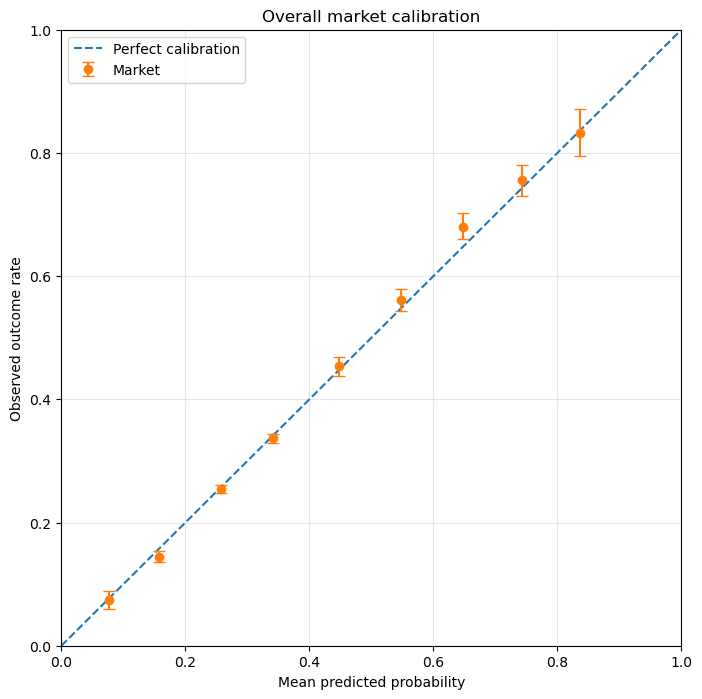

In [24]:
plot_data = overall_calibration.loc[
    (overall_calibration["n"] > 0)
    & (~overall_calibration["sparse"])
].copy()

yerr = np.vstack([
    plot_data["observed_outcome_rate"]
    - plot_data["observed_ci_low"],
    plot_data["observed_ci_high"]
    - plot_data["observed_outcome_rate"],
])

plt.figure(figsize=(8, 8))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.errorbar(
    plot_data["mean_predicted_probability"],
    plot_data["observed_outcome_rate"],
    yerr=yerr,
    fmt="o",
    capsize=4,
    label="Market",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed outcome rate")
plt.title("Overall market calibration")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 13. Plot calibration by outcome type

Create separate reliability charts for home, draw, and away selections using the same fixed bins and uncertainty framework.


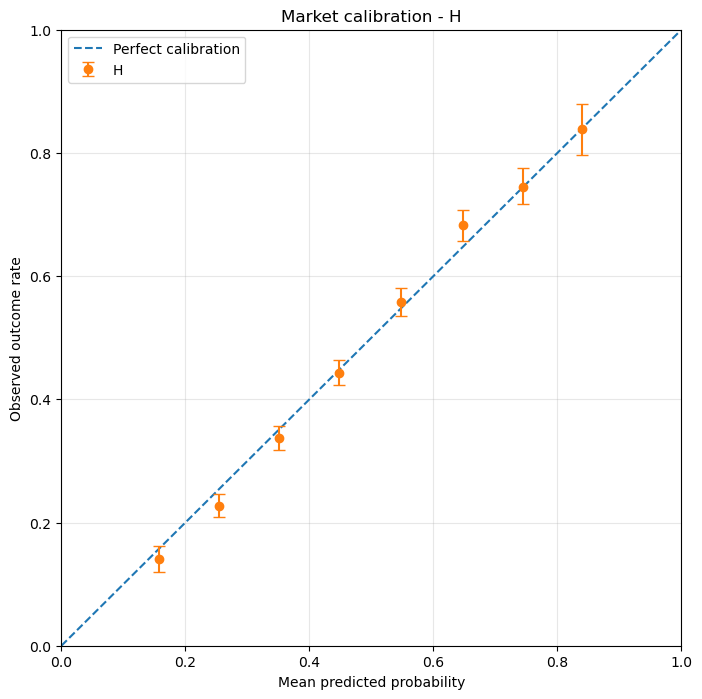

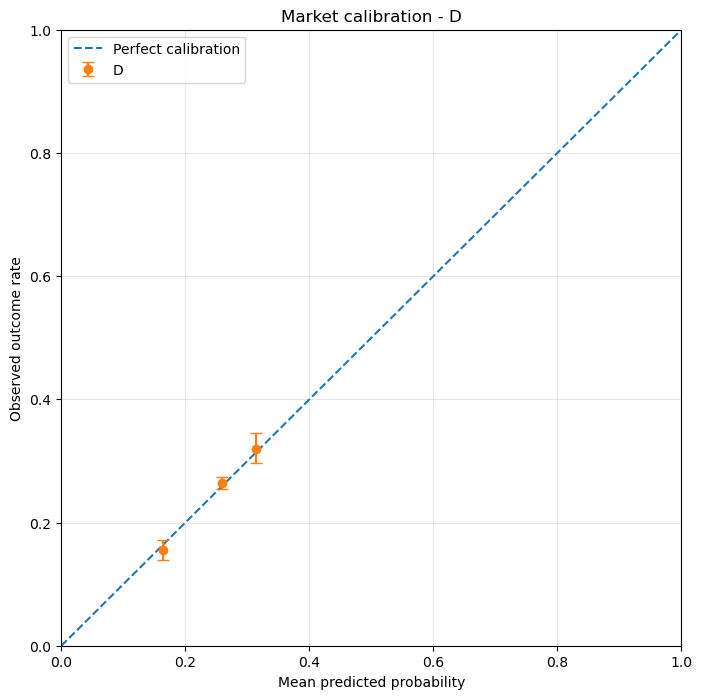

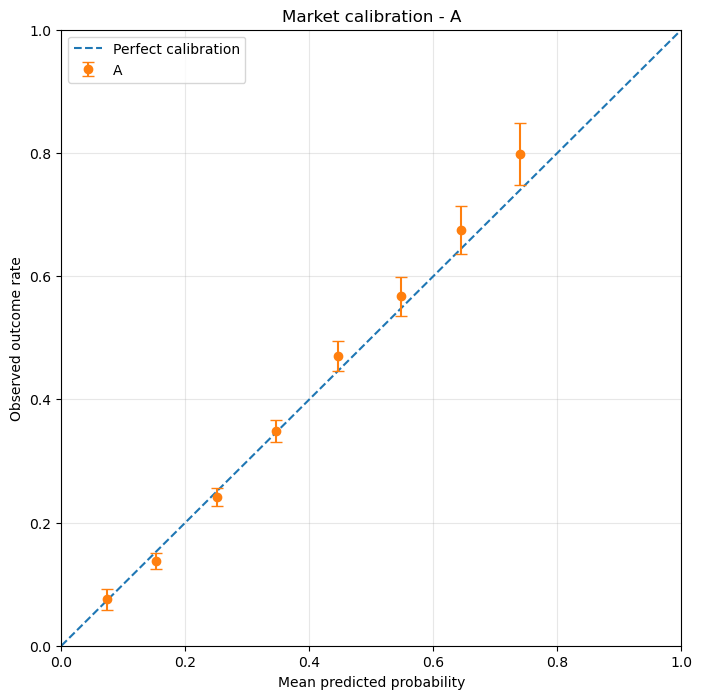

In [25]:
for selection_type in selection_order:
    
    plot_data = calibration_by_selection.loc[
    (calibration_by_selection["selection_type"] == selection_type)
    & (calibration_by_selection["n"] > 0)
    & (~calibration_by_selection["sparse"])
    ].copy()

    yerr = np.vstack([
        plot_data["observed_outcome_rate"]
        - plot_data["observed_ci_low"],
        plot_data["observed_ci_high"]
        - plot_data["observed_outcome_rate"],
    ])

    plt.figure(figsize=(8, 8))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.errorbar(
        plot_data["mean_predicted_probability"],
        plot_data["observed_outcome_rate"],
        yerr=yerr,
        fmt="o",
        capsize=4,
        label=selection_type,
    )



    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed outcome rate")
    plt.title(
        f"Market calibration - {selection_type}"
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

## 14. Plot Brier Score by league and season

Visualize the league and season Brier summaries to make differences in forecast error easier to compare before the data is exported to Power BI.


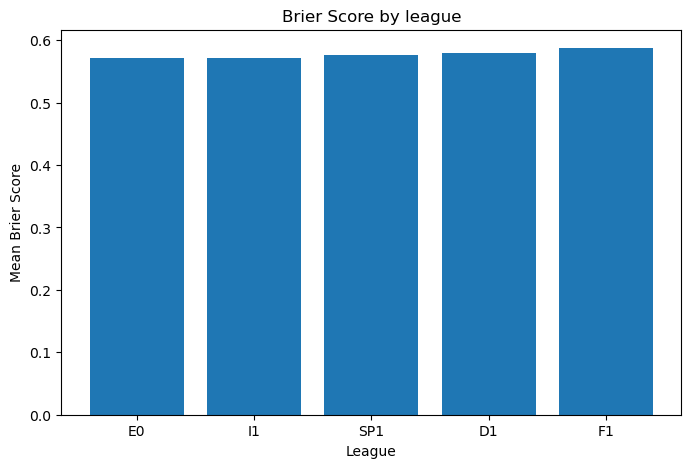

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    brier_by_league["div"],
    brier_by_league["mean_brier_score"],
)

plt.xlabel("League")
plt.ylabel("Mean Brier Score")
plt.title("Brier Score by league")

plt.show()

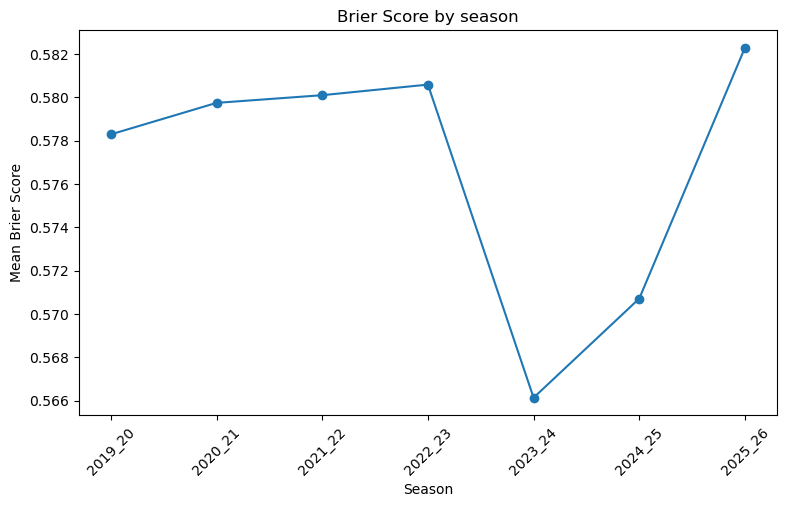

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    brier_by_season["season"],
    brier_by_season["mean_brier_score"],
    marker="o",
)

plt.xlabel("Season")
plt.ylabel("Mean Brier Score")
plt.title("Brier Score by season")
plt.xticks(rotation=45)

plt.show()

## 15. Export Power BI datasets

Write the validated overall, segmented, and Brier summary tables to `data/processed/`. These exported tables are the statistical source for the calibration page of the dashboard.


In [28]:
OUTPUT_DIR = REPO_ROOT / "data" / "processed"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [29]:
brier_summary = pd.DataFrame({
    "metric": [
        "market_brier",
        "climatology_brier",
    ],
    "value": [
        overall_brier,
        benchmark_brier,
    ],
})

In [30]:
overall_calibration.to_csv(
    OUTPUT_DIR / "calibration_overall.csv",
    index=False,
)

calibration_by_selection.to_csv(
    OUTPUT_DIR / "calibration_by_selection.csv",
    index=False,
)

calibration_by_league.to_csv(
    OUTPUT_DIR / "calibration_by_league.csv",
    index=False,
)

calibration_by_season.to_csv(
    OUTPUT_DIR / "calibration_by_season.csv",
    index=False,
)

brier_by_league.to_csv(
    OUTPUT_DIR / "brier_by_league.csv",
    index=False,
)

brier_by_season.to_csv(
    OUTPUT_DIR / "brier_by_season.csv",
    index=False,
)

brier_summary.to_csv(
    OUTPUT_DIR / "brier_summary.csv",
    index=False,
)

print("Calibration outputs exported.")

Calibration outputs exported.
